In [33]:
import bosperrus
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sys
sys.path.append("../src/utils/")
import enriched_adata as ea
from border_fit import ALL_SAMPLES, FIT_PALETTE, MIN_COMPONENT_SPOTS
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
DATASET_TYPE_MARKERS = {"visium_demo": "o", "visium_custom": "s", "stomics_custom": "^", "Visium HD": "s", "STOmics": "^"}

In [3]:
PATIENT_PAIRS = [
    ("Pat1", "A02991D1"), ("Pat2", "A02994C6"), ("Pat3", "Y01087DD"), ("Pat4", "Y01084J8"),
]

# Part 1: Visium HD Demo (spot-based border)

In [4]:
results = []
enriched_adatas = {}  # shared with Part 3 below -- built once here, reused there

In [5]:
for i, sample in enumerate(ALL_SAMPLES["name"].values):
    loader_type = ALL_SAMPLES["loader"].iloc[i]
    h5ad_path = ALL_SAMPLES["h5ad_path"].iloc[i]
    bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]

    adata = ea.get_or_build_enriched_adata(sample, loader_type, h5ad_path, bin_size_um)
    ea.ensure_analysis_buffer(adata, bin_size_um, MIN_COMPONENT_SPOTS)
    blade_by_component = ea.ensure_blade_thresholds(adata, bin_size_um, MIN_COMPONENT_SPOTS)
    enriched_adatas[sample] = adata

    components = adata.obs["components"].to_numpy()
    per_component = adata.uns["analysis_buffer_fit"]["per_component"]
    print(f"{sample}: {len(per_component)} component(s) > {MIN_COMPONENT_SPOTS} spots")

    for label, info in per_component.items():
        member_mask = components == label

        # piecewise_linear_b comes back in um (bin_size_um was passed above) --
        # don't rescale it again below; bsp_thresh (grid-step units) does.
        bsp_thresh_um_value = info["params"].get("piecewise_linear_b")  # None if ConstantFit won
        bsp_thresh = bsp_thresh_um_value / bin_size_um if bsp_thresh_um_value is not None else None

        blade_thresh, blade_thresh_corrected = blade_by_component[label]
        pct_affected = float(adata.obs["analysis_buffer"].to_numpy()[member_mask].mean() * 100)

        results.append([
            sample, label, f"{sample}_{label}", info["n_spots"],
            blade_thresh, bsp_thresh, blade_thresh_corrected,
            bin_size_um,
            blade_thresh * bin_size_um if blade_thresh is not None else np.nan,
            bsp_thresh_um_value if bsp_thresh_um_value is not None else np.nan,
            blade_thresh_corrected * bin_size_um if blade_thresh_corrected is not None else np.nan,
            pct_affected,
        ])

    ea.save_enriched_adata(adata, sample)

breast_cancer: 3 component(s) > 1000 spots
pancreas: 1 component(s) > 1000 spots
colon_cancer_ff: 1 component(s) > 1000 spots
breast_cancer_tma: 36 component(s) > 1000 spots
Pat1: 1 component(s) > 1000 spots
Pat2: 3 component(s) > 1000 spots
Pat3: 4 component(s) > 1000 spots
Pat4: 2 component(s) > 1000 spots
A02991D1: 1 component(s) > 1000 spots
A02994C6: 5 component(s) > 1000 spots
Y01087DD: 5 component(s) > 1000 spots
Y01084J8: 4 component(s) > 1000 spots


In [6]:
results_df = pd.DataFrame(results, columns=[
    "sample", "component_rank", "component_label", "component_size",
    "blade_thresh", "bsp_thresh", "blade_thresh_corrected",
    "bin_size_um", "blade_thresh_um", "bsp_thresh_um", "blade_thresh_corrected_um",
    "pct_affected",
])
results_df = results_df.merge(ALL_SAMPLES[["name", "dataset_type"]], left_on="sample", right_on="name")
counts = results_df["sample"].value_counts()
results_df["num_components"] = results_df["sample"].apply(lambda x: counts[x])
results_df["component_size_um"] = results_df["component_size"] * results_df["bin_size_um"] ** 2  # spot count -> physical area (um^2); bin_size_um differs across technologies (8 vs. 10), so raw component_size isn't comparable

In [7]:
demo_results_df = results_df[results_df["dataset_type"] == "visium_demo"]

In [8]:
sample_pal = dict()
pair_colors = sns.color_palette("Paired", 9)
results_df["pair"] = None

for (i, pair) in enumerate(PATIENT_PAIRS):
    sample_pal[pair[0]] = pair_colors[2 * i]
    sample_pal[pair[1]] = pair_colors[2 * i + 1]
    mask = results_df["sample"].isin(pair)
    results_df.loc[mask, "pair"] = "_".join(pair)

sample_pal.update({s: sns.color_palette("Purples", 4)[i] for (i, s) in enumerate(demo_results_df["sample"].unique())})

# Part 2: paired Custom Visium HD + STOmics (no component matching -- see `notebooks/exploratory/stomics_visium_phase_matching.ipynb` for why)

In [9]:
part2_df = results_df[results_df["dataset_type"].isin(["visium_custom", "stomics_custom"])].copy()
part2_df["technology"] = part2_df["dataset_type"].map({"visium_custom": "Visium HD", "stomics_custom": "STOmics"})

In [10]:
figure2_df = demo_results_df.sort_values(["dataset_type", "sample", "component_rank"]).reset_index(drop=True)
component_spacing = 1
sample_gap = 2

x_pos = []
x = 0
previous_sample = None

for _, row in figure2_df.iterrows():
    if previous_sample is not None:
        x += sample_gap if row["sample"] != previous_sample else component_spacing
    x_pos.append(x)
    previous_sample = row["sample"]

x_pos = np.array(x_pos)
figure2_df["x_pos"] = x_pos

# Part 3: RNA diffusion outside the image mask (all demo + custom samples)

In [11]:
mask_diffusion_results = []
for i, sample in enumerate(ALL_SAMPLES["name"].values):
    dataset_type = ALL_SAMPLES["dataset_type"].iloc[i]
    bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]

    adata = enriched_adatas[sample]  # already built + enriched with analysis_buffer_fit by Part 1's loop
    ea.ensure_diffusion(adata, bin_size_um, MIN_COMPONENT_SPOTS)
    ea.save_enriched_adata(adata, sample)

    for label, info in adata.uns["diffusion_fit"]["per_component"].items():
        n_spots = adata.obs["components"].value_counts().loc[label]
        result = {
            "sample": sample, "component_rank": label, "component_label": f"{sample}_{label}",
            "dataset_type": dataset_type, "n_outside": info["n_spots"], 
            "best_fit_type": info["best_fit_type"],
            "alpha": info["alpha"], "beta": info["beta"],
            "observed_effect_strength": info["observed_effect_strength"],
            "n_spots": n_spots,
            "component_size_um": n_spots * bin_size_um ** 2,  # same convention as results_df's own component_size_um
            "bin_size_um": bin_size_um
        }
        mask_diffusion_results.append(result)

mask_diffusion_df = pd.DataFrame(mask_diffusion_results)
mask_diffusion_df

,sample,component_rank,component_label,dataset_type,n_outside,best_fit_type,alpha,beta,observed_effect_strength,n_spots,component_size_um,bin_size_um
0,breast_cancer,0,breast_cancer_0,visium_demo,16713,Exponential Decay Fit,1.519388,0.003298,0.324216,1458864,93367296.0,8.0
1,breast_cancer,1,breast_cancer_1,visium_demo,219,Exponential Decay Fit,1.171522,0.027568,0.268802,1382,88448.0,8.0
2,breast_cancer,2,breast_cancer_2,visium_demo,381,Exponential Decay Fit,1.594140,0.019662,0.771357,1164,74496.0,8.0
3,pancreas,0,pancreas_0,visium_demo,14810,Exponential Decay Fit,17.748306,0.115207,1.000000,1246205,79757120.0,8.0
4,colon_cancer_ff,0,colon_cancer_ff_0,visium_demo,5285,Exponential Decay Fit,4.142515,0.006345,0.355913,1720047,110083008.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
61,Y01087DD,4,Y01087DD_4,stomics_custom,717,Exponential Decay Fit,0.938058,0.033522,0.764196,1551,155100.0,10.0
62,Y01084J8,0,Y01084J8_0,stomics_custom,9239,Exponential Decay Fit,4.867504,0.048052,0.958135,109694,10969400.0,10.0
63,Y01084J8,1,Y01084J8_1,stomics_custom,2648,Exponential Decay Fit,2.037193,0.003386,0.152335,8668,866800.0,10.0
64,Y01084J8,2,Y01084J8_2,stomics_custom,1183,Exponential Decay Fit,2.385141,0.013357,0.400545,5913,591300.0,10.0


In [12]:
mask_diffusion_df["1/beta"] = 1 / mask_diffusion_df["beta"] 

In [13]:
mask_diffusion_df["perc_outside"] = 100 * mask_diffusion_df["n_outside"] / mask_diffusion_df["n_spots"] 

In [14]:
mask_diffusion_df["component_size_um_inside"] = (mask_diffusion_df["n_spots"] - mask_diffusion_df["n_outside"]) * mask_diffusion_df["bin_size_um"] ** 2

In [15]:
for (i, pair) in enumerate(PATIENT_PAIRS):
    mask = mask_diffusion_df["sample"].isin(pair)
    mask_diffusion_df.loc[mask, "pair"] = "_".join(pair)

In [16]:
plot_df = mask_diffusion_df.dropna(subset=["alpha", "beta"])

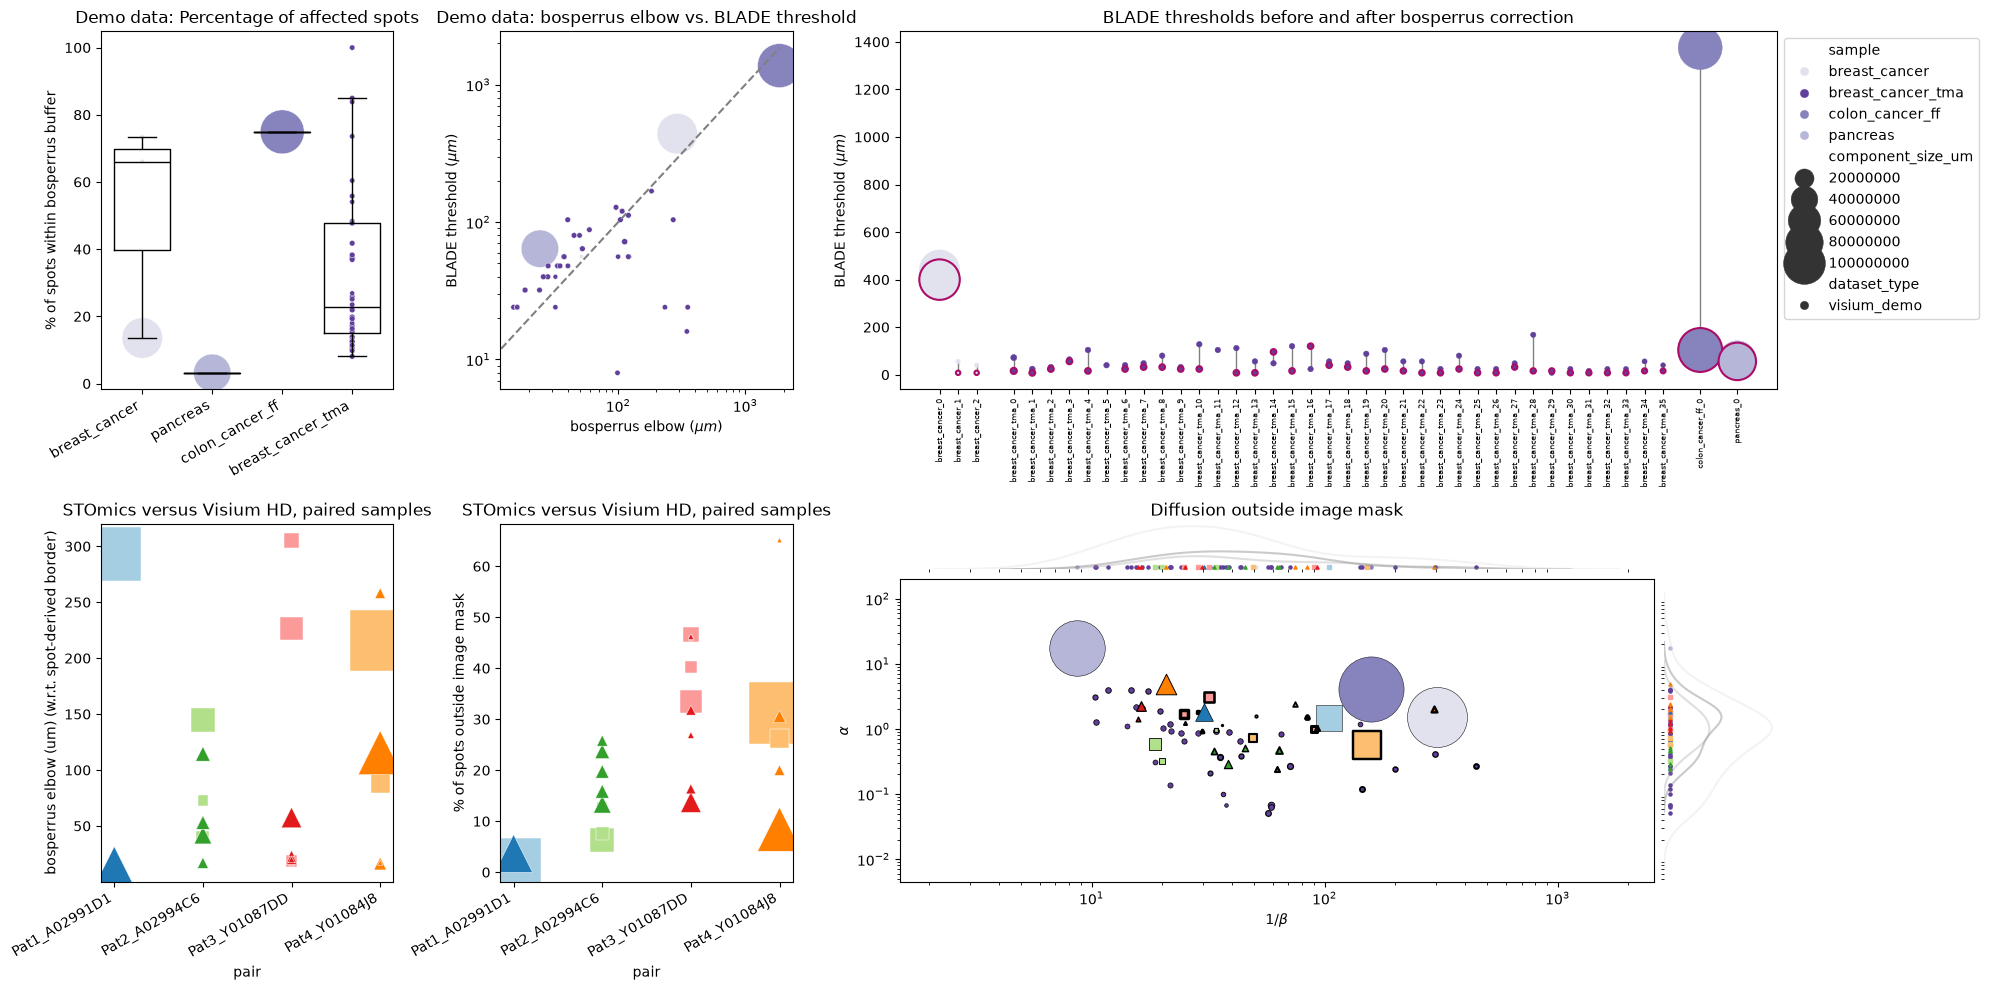

In [39]:
f, axs = plt.subplots(2, 3, figsize=(20, 10), width_ratios=[1, 1, 3])

# a: Demo data only. Which percentage of spots would need to be excluded according to bosperrus.
sns.boxplot(demo_results_df, x="sample", y="pct_affected", color="black", fill=False, showfliers=False, linewidth=1, ax=axs[0, 0])
sns.scatterplot(demo_results_df,  x="sample", y="pct_affected", style="dataset_type", hue="sample", size="component_size_um", markers=DATASET_TYPE_MARKERS, sizes=(10, 1000), palette=sample_pal, ax=axs[0, 0], legend=False)
axs[0, 0].set_ylabel("% of spots within bosperrus buffer")
axs[0, 0].set_xlabel("")
axs[0, 0].set_title("Demo data: Percentage of affected spots")
axs[0, 0].set_xticks(axs[0, 0].get_xticks(), axs[0, 0].get_xticklabels(), rotation=30, ha="right")

# b: Demo data only. Agreement of BLADE and bosperrus.
sns.scatterplot(demo_results_df, y="blade_thresh_um", x="bsp_thresh_um", style="dataset_type", hue="sample", size="component_size_um", markers=DATASET_TYPE_MARKERS, sizes=(10, 1000), palette=sample_pal, ax=axs[0, 1], legend=False)
max_val = np.max(demo_results_df[["blade_thresh_um", "bsp_thresh_um"]].values)
axs[0, 1].plot((0,max_val), (0, max_val), c="gray", ls="--")
axs[0, 1].set_title("Demo data: bosperrus elbow vs. BLADE threshold")
axs[0, 1].set_ylabel("BLADE threshold ($\\mu m$)")
axs[0, 1].set_xlabel("bosperrus elbow ($\\mu m$)")
axs[0, 1].set_yscale("log")
axs[0, 1].set_xscale("log")

# c: Demo data only. Bosperrus correction decreases BLADE identified buffer. 
for _, row in figure2_df.iterrows():
    axs[0, 2].plot([row["x_pos"], row["x_pos"]], [row["blade_thresh_um"], row["blade_thresh_corrected_um"]], color="gray", linewidth=1, zorder=0)

sns.scatterplot(data=figure2_df, x="x_pos", y="blade_thresh_um", hue="sample", style="dataset_type", markers=DATASET_TYPE_MARKERS, palette=sample_pal, sizes=(10, 1000), size="component_size_um", edgecolor=None, legend=True, ax=axs[0, 2], zorder=2)
sns.scatterplot(data=figure2_df, x="x_pos", y="blade_thresh_corrected_um", hue="sample", style="dataset_type", markers=DATASET_TYPE_MARKERS, palette=sample_pal, sizes=(10, 1000), size="component_size_um", edgecolor=FIT_PALETTE["Exponential Saturation Fit"], linewidth=1.5, legend=False, ax=axs[0, 2], zorder=2)

axs[0, 2].set_xticks(x_pos)
axs[0, 2].set_xticklabels(figure2_df["component_label"], rotation=90, fontsize=6)

axs[0, 2].set_xlabel("")
axs[0, 2].set_ylabel("BLADE threshold ($\\mu m$)")
axs[0, 2].set_title("BLADE thresholds before and after bosperrus correction")

#axs[0, 2].set_yscale("log")
sns.move_legend(axs[0, 2], "upper left", bbox_to_anchor=(1, 1))


# d: comparison of Visium HD and STOmics on paired samples via bosperrus elbows. no 1:1 matching of components possible, hence size encoding of components to somewhat facilitate comparison. 
de_size_min = min(part2_df["component_size_um"].min(), mask_diffusion_df["component_size_um"].min())
de_size_max = max(part2_df["component_size_um"].max(), mask_diffusion_df["component_size_um"].max())

sns.scatterplot(part2_df, x="pair", y="bsp_thresh_um", hue="sample", style="technology", palette=sample_pal, size="component_size_um", sizes=(10,10000), ax=axs[1, 0], legend=False, size_norm=(de_size_min, de_size_max), markers=DATASET_TYPE_MARKERS)
axs[1, 0].set_ylabel("bosperrus elbow (um) (w.r.t. spot-derived border)")
axs[1, 0].set_title("STOmics versus Visium HD, paired samples")
axs[1, 0].set_xticks(axs[1, 0].get_xticks(), axs[1, 0].get_xticklabels(), rotation=30, ha="right")

# e: comparison of Visium HD and STOmics on paired samples via percentage of spots outside of tissue image mask. no 1:1 matching of components possible, hence size encoding of components to somewhat facilitate comparison. 
sns.scatterplot(mask_diffusion_df, x="pair", y="perc_outside", hue="sample", style="dataset_type", palette=sample_pal, size="component_size_um", sizes=(10,10000), ax=axs[1, 1], legend=False, size_norm=(de_size_min, de_size_max), markers=DATASET_TYPE_MARKERS)
axs[1, 1].set_ylabel("% of spots outside image mask")
axs[1, 1].set_title("STOmics versus Visium HD, paired samples")
axs[1, 1].set_xticks(axs[1, 1].get_xticks(), axs[1, 1].get_xticklabels(), rotation=30, ha="right")


# f: comparison of Visium HD and STOmics diffusion outside of image mask via Exponential Decay model fit.
# Filled marker: color=sample, shape=dataset_type, size=component_size_um, black edge linewidth=perc_outside
# (wide 0.3-3.0pt range so it's actually visible -- the previous white-fill/thin-edge version made this
# unreadable, and an earlier overlaid-marker version had a size_norm bug that made shapes look "rotated").
lw_min, lw_max = 0.3, 5.0
plot_df["linewidth"] = lw_min + (plot_df["perc_outside"] / 100) * (lw_max - lw_min)
for _, row in plot_df.iterrows():
    axs[1, 2].scatter(row["1/beta"], row["alpha"], s=row["component_size_um"] / 5e4,
                       marker=DATASET_TYPE_MARKERS[row["dataset_type"]], facecolor=sample_pal[row["sample"]],
                       edgecolor="black", linewidth=row["linewidth"], alpha=1)

TECHNOLOGY_MARGIN_PALETTE = {"visium_demo": "purple", "visium_custom": "lightgray", "stomics_custom": "dimgray"}

divider = make_axes_locatable(axs[1, 2])
ax_top = divider.append_axes("top", size="15%", pad=0.1, sharex=axs[1, 2])
ax_right = divider.append_axes("right", size="15%", pad=0.1, sharey=axs[1, 2])

sns.kdeplot(data=plot_df, x="1/beta", hue="dataset_type", log_scale=True, fill=False, alpha=0.3, legend=False, ax=ax_top, palette=sns.color_palette("Grays", 3))
sns.kdeplot(data=plot_df, y="alpha", hue="dataset_type", log_scale=True, fill=False, alpha=0.3, legend=False, ax=ax_right, palette=sns.color_palette("Grays", 3))

for _, row in plot_df.iterrows():
    ax_top.scatter(row["1/beta"], 0.05, marker=DATASET_TYPE_MARKERS[row["dataset_type"]], color=sample_pal[row["sample"]],
                   s=5, alpha=1, clip_on=False, transform=ax_top.get_xaxis_transform())
    ax_right.scatter(0.05, row["alpha"], marker=DATASET_TYPE_MARKERS[row["dataset_type"]], color=sample_pal[row["sample"]],
                      s=5, alpha=1, clip_on=False, transform=ax_right.get_yaxis_transform())

for ax in (ax_top, ax_right):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
axs[1, 2].set_xscale("log")
axs[1, 2].set_yscale("log")
axs[1, 2].set_ylabel("$\\alpha$")
axs[1, 2].set_xlabel("$1/\\beta$")
ax_top.set_title("Diffusion outside image mask")

plt.tight_layout()
plt.show()